In [1]:
import sys
sys.path.insert(0, '../src')

import priceModels as pm
import amOptPricer as aop

import numpy as np
import matplotlib.pyplot as plt

## Improved Stein-Stein (LLH) model of the price dynamics

\begin{align}
    \frac{dS_t}{S_t} &= rdt + \sigma_tdW^1_t\\
    d\sigma_t &= \kappa(\theta_t-\sigma_t)dt + \nu dW^2_t\\
    d\theta_t &= \lambda dt + \eta dB_t\\
    dB_t &= B_t dW_t,\,B_0=1\\
    \text{ }\notag\\
    \text{cov}&(W^1_t,W^2_t)=\rho t \notag
\end{align}

- $W^1_t,\,W^2_t$ are correlated brownian motions, $W_t$ independent brownian motion
- $\Theta = (\kappa,\,\nu,\,\lambda,\,\eta,\, \rho)$ are the model parameters

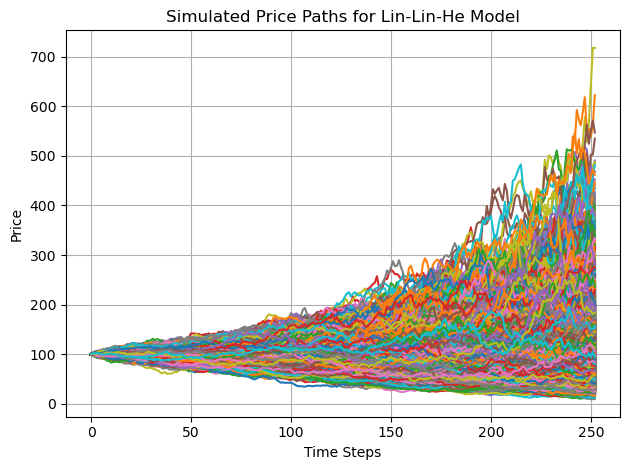

In [9]:
#r=0.01,  kappa=5, nu=0.2, sigma0=0.15, theta0=0.18, lam=0.9, eta=0.01, rho=-0.2, from the Lin-Lin-He paper Table 1
model_llh = pm.ImprovedSteinStein(
        r=0.01, rho=-0.2, kappa=5, nu=0.2,
        sigma0=0.15, theta0=0.18, lam=0.9, eta=0.01, seed=123
    )

# Simulate 10,000 paths for 1 year horizon (T=1.0) with 252 trading days
res_llh = model_llh.simulate_prices(S0=100.0, T=1.0, n_steps_mc=252, n_paths=10000)

# Plot the simulated price paths
pm.plot(res_llh['S'].T, title="Simulated Price Paths for Lin-Lin-He Model")

In [ ]:
# #r=0.3943,  kappa=4.9394, nu=0.4, sigma0=0.2924, theta0=0.1319, lam=0.3115, eta=0.4112, rho=0.1691 from the Lin-Lin-He papaer Table 2
# model_llh = pm.ImprovedSteinStein(
#         r=0.3943, rho=0.1691, kappa=4.9394, nu=0.4,
#         sigma0=0.2924, theta0=0.1319, lam=0.3115, eta=0.4112, seed=123
#     )

# # Simulate 10,000 paths for 1 year horizon (T=1.0) with 252 trading days
# res_llh = model_llh.simulate_prices(S0=100.0, T=1.0, n_steps_mc=252, n_paths= 10000)

# # Plot the simulated price paths
# pm.plot(res_llh['S'].T, title="Simulated Price Paths for Lin-Lin-He Model")

#### 1. Simulate Price Paths

We illustrate how to simulate price paths from the LLH model using Algorithm 2.5 detailed in the report. The values of the model parameters have been selected from the Lin-Lin-He paper, Table 2. Ten thousand paths have been sampled over a 1 year horizon with 252 trading days.

#### 2. Compute European Prices

We illustrate the computation of European options using the algorithm outlined in section 3.1 of the report (the "exact" LLH formula of the European price). Furthermore, we perform a Monte Carlo simulation of $1 ,000,000$ paths to estimate the price of vanilla european options under the LLH model and we compare the results with the results of the LLH price formula.

- Consider a 1 month horizon ($T = 0.083$ yr) with 22 trading days. 

In [ ]:
def llh_european_prices(model, S0=100.0, K=90.0, tau=1.0, 
                        n_steps_mc=256, n_paths=1_000_000,
                        phi_max=200.0, n_phi=1023, n_steps_ode=252):
    """
    Compute the prices of European call and put using the LLH formula and MC simulations.
    
    The LLH analytical formula uses the characteristic function approach with ODE 
    coefficients computed via RK4 integration. The implementation correctly accounts 
    for the tau term in equation (4) of the Lin-Lin-He paper, treating it as a 
    non-autonomous ODE system.
    
    Parameters:
      model       : ImprovedSteinStein model instance
      S0          : initial spot price
      K           : strike price
      tau         : time to maturity
      n_steps_mc  : number of MC time discretization steps
      n_paths     : number of MC paths
      phi_max     : maximum phi value for integration
      n_phi       : number of phi nodes for trapezoid quadrature
      n_steps_ode : number of RK4 steps for ODE integration
    """
    
    # Simulate paths for MC pricing
    res = model.simulate_prices(S0=S0, T=tau, n_steps_mc=n_steps_mc, n_paths=n_paths)
    
    # European call price using LLH analytical formula
    price_call = model.price_call_llh(S=S0, K=K, tau=tau, 
                                      vol=model.sigma0, theta=model.theta0,
                                      phi_max=phi_max, n_phi=n_phi, n_steps_ode=n_steps_ode).item()
    
    # European put price using LLH analytical formula
    price_put = model.price_put_llh(S=S0, K=K, tau=tau, 
                                     vol=model.sigma0, theta=model.theta0,
                                     phi_max=phi_max, n_phi=n_phi, n_steps_ode=n_steps_ode).item()
    
    # Monte Carlo pricing using the simulated paths
    res_mc = aop.price_call_mc(res['S'], K=K, T=tau, r=model.r)
    price_put_mc = res_mc.get('price') - S0 + K * np.exp(-model.r * tau)

    return {"European call LLH price": price_call,
            "European call MC price": res_mc.get('price'),
            "MC 95% CI": res_mc.get('ci_95'),
            "European put LLH price": price_put,
            "European put MC price": price_put_mc}

In [ ]:
S = [90.0, 95.0, 100.0, 105.0, 110.0]
K = [0.9*s for s in S]
n_paths = 1_000_000
tau = 0.083
n_steps_mc = 22  # MC discretization steps
n_steps_ode = 100  # ODE integration steps
phi_max = 300.0
n_phi = 3000 # integration nodes

prices_llh = {}
prices_mc = {}
for k, s in zip(K, S):
    res = llh_european_prices(model_llh, S0=s, K=k, tau=tau, 
                             n_steps_mc=n_steps_mc, n_paths=n_paths,
                             phi_max=phi_max, n_phi=n_phi, n_steps_ode=n_steps_ode)
    prices_llh[s] = res["European call LLH price"]
    prices_mc[s] = res["European call MC price"]

In [ ]:
prices_llh

In [ ]:
prices_mc

In [ ]:
bias = {s: np.round((prices_mc[s] - prices_llh[s])/prices_mc[s]*100,2) for s in S}
bias

In [ ]:
pm.compare_european_prices(model_llh, S0=100.0, K=90.0, tau=0.083, n_steps_mc=22, n_paths=1000000, phi_max=1000, n_phi=2500,n_steps_ode=5000)

- Consider a 1 year horizon with 252 trading days. 

In [ ]:
pm.compare_european_prices(model_llh, S0=100.0, K=90.0, tau=1.0, n_steps_mc=52, n_paths=50000, phi_max=1000, n_phi=2500, n_steps_ode=5000)

#### Remarks
- Recall the call-put parity: $P-C=Ke^{-t\tau}-S$ which implies that $P_E^{llh}-P^{MC}_E=C_E^{llh}-C^{MC}_E$
- Notice the bias in the LLH price that accentuates with longer maturity. The implementation of the "exact" LLH price seems to be consistently underevaluating the euporean price. The bias is due to the errors that result from the estimation of the ODE system and the integrals involved in the LLH formula. Further investigation is required.

## Validate the Implementation on edge Cases 

### 1. Black-Scholes limit: $\kappa=\nu=\lambda=\eta=\rho=0$

#### 1.1 Simulate Price Paths

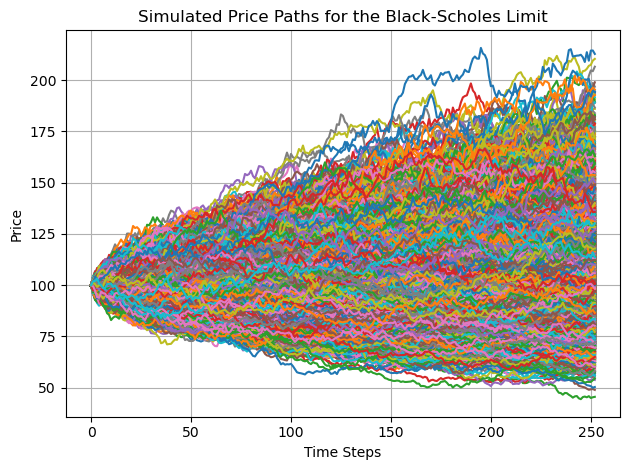

In [10]:
# BS limit: no volatility dynamics kappa=nu=lambda=eta=rho=0 → price is Log-Normal
model_bs_limit = pm.ImprovedSteinStein(
        r=0.05, rho=0.0, kappa=0.0, nu=0.0,
        sigma0=0.2, theta0=0.0, lam=0.0, eta=0.0, seed=123
    )

res_bs = model_bs_limit.simulate_prices(S0=100.0, T=1.0, n_steps_mc=252, n_paths= 10000)
pm.plot(res_bs['S'].T, title="Simulated Price Paths for the Black-Scholes Limit")

#### Test of Lognormality of the generated price paths

We draw price paths from the LLH (BS-limit) model and consider the price slice at the end of the simulation horizon $T$. The distribution of the  price slice  should match the BS distribution at time $T$, that is a log normal distribution. We test this hypothesis by using a utility function from the priceModles module.

In [ ]:
pm.test_lognormality(res_bs['S'][:,-1])

#### 1.2 Compare European Option Prices

Compare the LLH (BS-limit) formula price with the BS call price and with the Monte Carlo price.

In [12]:
# BS limit → price must match Black–Scholes
S, K, tau, vol, theta = 100,90,1.0,0.2, 0.0
price_llh = model_bs_limit.price_call_llh(S, K, tau, vol, theta).item()  

# Black–Scholes benchmark:
price_bs = aop.price_call_bs(S=100, K=90, tau=1.0, r=0.05, vol=0.2)

# Monte Carlo pricing using the simulated paths
price_mc = aop.price_call_mc(res_bs['S'], K=90, T=1.0, r=0.05).get('price')
print(f"Improved Stein-Stein (BS-limit) = {price_llh:.10f},\nBlack-Scholes = {price_bs:.10f},\n|\u0394| = {abs(price_llh-price_bs):.3e},\nMonte Carlo = {price_mc:.10f}")

Improved Stein-Stein (BS-limit) = 16.6994484084,
Black-Scholes = 16.6994484084,
|Δ| = 5.684e-14,
Monte Carlo = 16.5898217133


### 2. Stein-Stein limit:  $\lambda=\eta=\rho=0$

#### 2.1 Simulate Price Paths

In the Stein-Stein paper:
$\delta = \kappa =4, \quad k = \nu = 0.1,\quad \mu = r = 0.0953, \quad \sigma = vol = 0.2$


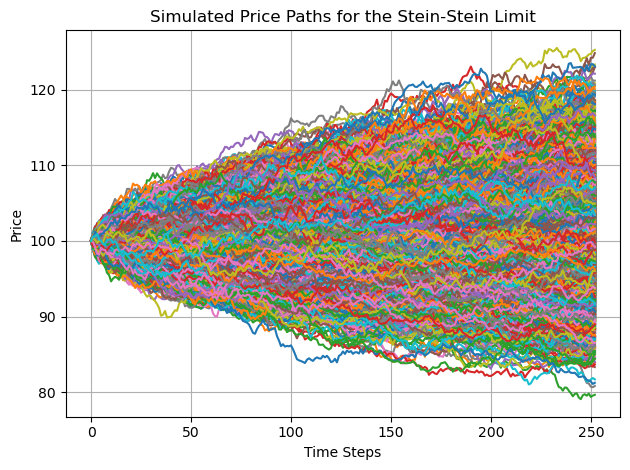

In [13]:
# Stein-Stein limit: rho=0.0, lam=0.0, eta=0.0 
# Param values and option price taken from  the Stein-Stein paper Table 1; 
#r=0.0953,  kappa=4.0, nu=0.1, sigma0=0.2, theta0=0.2

# Stein-Stein limi → price must match Stein-Stein
model_ss_limit = pm.ImprovedSteinStein(
        r=0.0953, rho=0.0, kappa=4.0, nu=0.1,
        sigma0=0.2, theta0=0.2, lam=0.0, eta=0.0, seed=123
    )

res_ss = model_ss_limit.simulate_prices(S0=100.0, T=1.0/12, n_steps_mc=252, n_paths= 10000)

pm.plot(res_ss['S'].T, title="Simulated Price Paths for the Stein-Stein Limit")

#### 2.2 Compare European Option prices

In [14]:
# SS limit→ price must match Stein-Stein
S, K, tau, vol, theta = 100,90,1/12,0.2, 0.2
price_llh = model_ss_limit.price_call_llh(S, K, tau, vol, theta)  


In [16]:
price_llh = price_llh.item()

In [17]:
# Stein-Stein benchmark:
price_ss = 10.77 # from the Stein-Stein paper Table 1
print(f"Prototype (SS-limit) = {price_llh:.10f},  Stein-Stein = {price_ss:.10f},  |\u0394| = {abs(price_llh-price_ss):.3e}")

# Monte Carlo pricing using the simulated paths
price_mc = aop.price_call_mc(res_ss['S'], K=90, T=.0/12, r=0.0953)['price']
print(f"Monte Carlo price= {price_mc:.10f}")

Prototype (SS-limit) = 10.7668609302,  Stein-Stein = 10.7700000000,  |Δ| = 3.139e-03
Monte Carlo price= 10.8147914088


## 5. Comparison with Schöbel-Zhu (1999) Table 2 — Impact of $\\theta_0$

Schöbel-Zhu (1999) Table 2 studies the impact of the long-run mean $\\theta_0$ on European call option prices across three correlation regimes (Panel D: $\\rho=0.5$, Panel E: $\\rho=0.0$, Panel F: $\\rho=-0.5$). These are **SS-limit** parameters ($\\lambda=\\eta=0$), so the LLH formula is exact in this case.  For each panel we compute the LLH (SS-limit) call price via the analytical formula and compare with a Monte Carlo estimate and Black-Scholes, following the same pattern used in §1 of this notebook.

In [ ]:
import pandas as pd

# ── S&Z Table 2 shared parameters (SS limit: lam=eta=0) ──────────────────────
r_sz, kappa_sz, nu_sz = 0.0953, 4.0, 0.1
sigma0_sz = 0.15          # v (initial vol) in S&Z Table 2
tau_sz    = 0.5
S_sz      = 100.0
K_sz      = [90, 95, 100, 105, 110, 115, 120]
theta_values = [0.0, 0.1, 0.2, 0.3]

# Panels D, E, F differ only in rho
panels = {"D (ρ=0.5)": 0.5, "E (ρ=0.0)": 0.0, "F (ρ=−0.5)": -0.5}

In [ ]:
# ── Black-Scholes benchmark (σ₀=0.15, same for all panels) ──────────────────
bs_prices = {K: aop.price_call_bs(S=S_sz, K=K, tau=tau_sz, r=r_sz, vol=sigma0_sz)
             for K in K_sz}
print('Black-Scholes prices (vol=0.15):',
      {K: round(v, 4) for K, v in bs_prices.items()})

In [ ]:
# ── Loop over panels and θ₀ values ──────────────────────────────────────────
# For each panel build a DataFrame: rows = BS / LLH θ=x / MC θ=x, cols = strikes
for panel_name, rho_val in panels.items():
    print(f'\n=== Panel {panel_name} ===')
    rows = {'BS': bs_prices}
    for theta0_val in theta_values:
        model_sz = pm.ImprovedSteinStein(
            r=r_sz, rho=rho_val, kappa=kappa_sz, nu=nu_sz,
            sigma0=sigma0_sz, theta0=theta0_val, lam=0.0, eta=0.0, seed=123
        )
        llh_row = {}
        mc_row  = {}
        for K in K_sz:
            res = pm.compare_european_prices(
                model_sz, S0=S_sz, K=K, tau=tau_sz,
                n_steps_mc=52, n_paths=200_000,
                phi_max=300.0, n_phi=513, n_steps_ode=128
            )
            llh_row[K] = round(res['llh_call'], 4)
            mc_row[K]  = round(res['mc_call'],  4)
        rows[f'LLH θ₀={theta0_val}'] = llh_row
        rows[f'MC  θ₀={theta0_val}'] = mc_row
    df = pd.DataFrame(rows, index=K_sz).T
    df.index.name = f'Panel {panel_name} / K'
    display(df)

### Remarks

- **Stationary case** ($\\theta_0 = \\sigma_0 = 0.15$): the model starts at its long-run mean, so LLH and BS should agree most closely.
- **LLH formula bias**: the systematic ~3–5\% underpricing observed in §1 applies equally here; the MC column is the ground truth.  The bias shrinks for short maturities (here $\\tau=0.5$) and grows with $\\tau$.
- **Correlation effect**: negative $\\rho$ raises OTM put / ITM call prices relative to BS (leverage effect), while positive $\\rho$ has the opposite effect — visible by comparing Panels D and F across the same $\\theta_0$ row.
- **Long-run mean effect**: increasing $\\theta_0$ above $\\sigma_0=0.15$ raises future expected volatility, increasing all option prices; decreasing $\\theta_0$ below $\\sigma_0$ has the opposite effect.